In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/LICENSE
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/README.md
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50-human.xlsx
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-257349-A-15.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-195557-A-19.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/2-122820-B-36.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-115920-A-22.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-172649-C-40.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/

In [2]:
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import librosa.display
import matplotlib.pyplot as plt
import random
import torch

import warnings
warnings.filterwarnings("ignore")

In [3]:
DATA_SEED = 67
TRAINING_SEED = 1234
SR = 22050
DURATION = 5.0
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
TOP_DB=20
TARGET_SNR_DB = 10

random.seed(DATA_SEED)
np.random.seed(DATA_SEED)
torch.manual_seed(DATA_SEED)
torch.cuda.manual_seed(DATA_SEED)

In [4]:
# CONFIGURATION
DATA_ROOT = r'/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems' # Enter dataset path
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock'] # Make the list of all genres available (alphabetical order)
STEMS = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav'] # Write here stems file name
STEM_KEYS = ['drums', 'vocals', 'bass', 'other']
GENRE_TO_TEST = 'rock'
SONG_INDEX = 0 #Enter index as per Q10.


In [5]:
def build_dataset(root_dir, val_split=0.17, seed=42):
    # Initialize empty dictionaries
    train_dataset = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}
    val_dataset   = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}

    rng = random.Random(seed)

    # ------------------- write your code here -------------------------------
    cnt_lt_4kb = 0
    cnt_lt_5_0491 = 0
    cnt_gt_5_0493 = 0

    for genre in GENRES:
        genre_path = os.path.join(root_dir, genre)
        if not os.path.exists(genre_path):
            continue
            
        song_dirs = sorted([d for d in os.listdir(genre_path) if os.path.isdir(os.path.join(genre_path, d))])
        valid_songs = []
        for song_dir in song_dirs:
            song_path = os.path.join(genre_path, song_dir)
            files = os.listdir(song_path)
            
            # Check completeness
            if not all(stem in files for stem in STEMS):
                continue
                
            is_corrupt = False
            for stem in STEMS:
                size = os.path.getsize(os.path.join(song_path, stem))
                # Check corruption (less than 4kb)
                if size < 4 * 1024:
                    cnt_lt_4kb += 1
                    is_corrupt = True
                
                if size < 5.0491 * 1024 * 1024:
                    cnt_lt_5_0491 += 1
                if size > 5.0493 * 1024 * 1024:
                    cnt_gt_5_0493 += 1
                    
            if not is_corrupt:
                valid_songs.append(song_path)
                
        # Stratified Shuffle Split
        rng.shuffle(valid_songs)
        split_idx = int(len(valid_songs) * (1 - val_split))
        
        train_songs = valid_songs[:split_idx]
        val_songs = valid_songs[split_idx:]
     #-------------------------------------------------------------------------

        # Helper function to populate dict
        def add_to_dict(target_dict, song_list):
            for song_path in song_list:
                for stem in STEMS:
                    stem_key = stem.replace('.wav', '')
                    target_dict[genre][stem_key].append(os.path.join(song_path, stem))

        add_to_dict(train_dataset, train_songs)
        add_to_dict(val_dataset, val_songs)

    print("Q1. What is the value of total number of corrupted sounds ( less than 4kb) + (total number of sounds < 5.0491MB):")
    print(cnt_lt_4kb + cnt_lt_5_0491)

    print("\nQ2. What is the absolute difference between total number of sounds > 5.0493MB and total number of sounds < 5.0491MB ?")
    print(abs(cnt_gt_5_0493 - cnt_lt_5_0491))

    print("\nQ3. What is the absolute difference between the number of training reggae drum samples and the number of validation country vocal samples?")
    print(abs(len(train_dataset['reggae']['drums']) - len(val_dataset['country']['vocals'])))

    return train_dataset, val_dataset

tr, val = build_dataset(DATA_ROOT)


Q1. What is the value of total number of corrupted sounds ( less than 4kb) + (total number of sounds < 5.0491MB):
1256

Q2. What is the absolute difference between total number of sounds > 5.0493MB and total number of sounds < 5.0491MB ?
1072

Q3. What is the absolute difference between the number of training reggae drum samples and the number of validation country vocal samples?
66


In [6]:
def find_long_silences(dataset_dict, sr=SR, threshold_sec=DURATION, top_db=TOP_DB):
    """
    Input:
        dataset_dict: The dictionary structure {genre: {stem: [paths...]}}
    Output:
        df: Pandas DataFrame containing details of all files with silence >= 5s
    """
    records = []
    # ------------------- write your code here -------------------------------

    total_files = sum(len(stems) for genre_dict in dataset_dict.values() for stems in genre_dict.values())
    
    for genre, stems_dict in tqdm(dataset_dict.items(), desc="Genres"):
        for stem_name, paths in stems_dict.items():
            for file_path in paths:
                y, _sr = librosa.load(file_path, sr=sr)
                total_duration = len(y) / sr
                non_silent_intervals = librosa.effects.split(y, top_db=top_db)
                
                max_silence = 0
                silence_type = []
                
                if len(non_silent_intervals) == 0:
                    max_silence = total_duration
                    silence_type.append("fully_silent")
                else:
                    start_silence = non_silent_intervals[0][0] / sr
                    if start_silence > max_silence:
                        max_silence = start_silence
                        silence_type = ["start"]
                    elif start_silence == max_silence and start_silence > 0:
                        silence_type.append("start")
                        
                    end_silence = (len(y) - non_silent_intervals[-1][1]) / sr
                    if end_silence > max_silence:
                        max_silence = end_silence
                        silence_type = ["end"]
                    elif end_silence == max_silence and end_silence > 0:
                        silence_type.append("end")
                        
                    for i in range(len(non_silent_intervals) - 1):
                        gap = (non_silent_intervals[i+1][0] - non_silent_intervals[i][1]) / sr
                        if gap > max_silence:
                            max_silence = gap
                            silence_type = ["middle"]
                        elif gap == max_silence and gap > 0:
                            if "middle" not in silence_type:
                                silence_type.append("middle")
                
                if max_silence >= threshold_sec:
                    records.append({
                        "Genre": genre,
                        "Stem": stem_name,
                        "Duration": round(total_duration, 2),
                        "Max_Silence_Sec": round(max_silence, 2),
                        "Silence_Location": "middle" if silence_type == ["middle"] else ", ".join(sorted(list(set(silence_type)))) if silence_type else "",
                        "File_Path": file_path
                    })
    #-------------------------------------------------------------------------
    df = pd.DataFrame(records)
    return df


# --- EXECUTION ---
# Pass your 'tr' (training) dictionary here.
# Ensure 'tr' is defined from your previous build_dataset code.
df_silence = find_long_silences(tr, threshold_sec=DURATION, top_db=TOP_DB)

# --- RESULTS ANALYSIS ---

# ------------------- write your code here -------------------------------
print(f"Q4. Total number of sound files having silence greater than equal to 5 secs: {len(df_silence)}")

vocal_silences = df_silence[df_silence['Stem'] == 'vocals']
print(f"Q5. Total number of sound tracks in Vocals where silence >= 5 secs: {len(vocal_silences)}")
print(f"Q6. What's the average Silence Length in Vocals (in secs): {vocal_silences['Max_Silence_Sec'].mean()}")

jazz_drums = df_silence[(df_silence['Stem'] == 'drums') & (df_silence['Genre'] == 'jazz')]
print(f"Q7. Total number of drums sound tracks in jazz where silence >= 5 secs: {len(jazz_drums)}")

jazz_drums_mid = jazz_drums[jazz_drums['Silence_Location'] == 'middle']
print(f"Q8. Total number of drums sound tracks in jazz where silence >= 5 secs and Silence_Location is only middle: {len(jazz_drums_mid)}")

jazz_drums_max_10 = jazz_drums[jazz_drums['Max_Silence_Sec'] >= 10]
print(f"Q9. Total number of drums sound tracks in jazz where silence >= 5 secs and Max_Silence_Sec >= 10: {len(jazz_drums_max_10)}")

# Hint: Create a pivot Table: Count by Genre vs Stem
pivot_df = df_silence.pivot_table(index='Genre', columns='Stem', values='File_Path', aggfunc='count', fill_value=0)
display(pivot_df)
#-------------------------------------------------------------------------


Genres: 100%|██████████| 10/10 [07:21<00:00, 44.19s/it]

Q4. Total number of sound files having silence greater than equal to 5 secs: 680
Q5. Total number of sound tracks in Vocals where silence >= 5 secs: 304
Q6. What's the average Silence Length in Vocals (in secs): 12.590789473684211
Q7. Total number of drums sound tracks in jazz where silence >= 5 secs: 24
Q8. Total number of drums sound tracks in jazz where silence >= 5 secs and Silence_Location is only middle: 16
Q9. Total number of drums sound tracks in jazz where silence >= 5 secs and Max_Silence_Sec >= 10: 7


Stem,bass,drums,other,vocals
Genre,,,,
blues,17,22,5,43
classical,68,57,5,69
country,16,16,2,16
disco,8,2,3,18
hiphop,20,3,22,6
jazz,25,24,1,70
metal,6,2,1,40
pop,10,5,2,4
reggae,5,4,7,12


In [7]:
stems_audio = []
try:
    for key in STEM_KEYS:
        # ------------------- write your code here -------------------------------
        # Load audio (Duration 5.0s for speed/consistency)
        stem_path = tr[GENRE_TO_TEST][key][SONG_INDEX] if len(tr[GENRE_TO_TEST][key]) > 0 else val[GENRE_TO_TEST][key][SONG_INDEX]
        # In build_dataset, we preserved absolute paths. So stem_path is the absolute path.
        # But wait, Q10 instruction says "Select the first song from the 'rock' genre".
        # We set GENRE_TO_TEST = 'rock' and SONG_INDEX = 0
        rock_songs = sorted([d for d in os.listdir(os.path.join(DATA_ROOT, GENRE_TO_TEST)) if os.path.isdir(os.path.join(DATA_ROOT, GENRE_TO_TEST, d))])
        song_dir = rock_songs[SONG_INDEX]
        song_path = os.path.join(DATA_ROOT, GENRE_TO_TEST, song_dir)
        exact_stem_path = os.path.join(song_path, key + '.wav')
        
        y, _sr = librosa.load(exact_stem_path, sr=SR, duration=DURATION)
        stems_audio.append(y)
        #-------------------------------------------------------------------------

    print("Audio loaded successfully.")
except NameError:
    print("ERROR: 'tr' dictionary not found. Please run build_dataset() first.")
except IndexError:
    print(f"ERROR: Song index {SONG_INDEX} out of range for genre {GENRE_TO_TEST}.")
except Exception as e:
    print(f"ERROR: {e}")


Audio loaded successfully.


In [8]:
# ------------------- write your code here -------------------------------
# Stack them into a numpy array (Shape: 4 x Samples)
stems_stack = np.array(stems_audio)

# Mix the stems by summing them element-wise
mix_raw = np.sum(stems_stack, axis=0)

# Calculate RMS Amplitude MANUALLY
rms_val = np.sqrt(np.mean(mix_raw**2))

#Peak Normalization
max_val = np.max(np.abs(mix_raw))

if max_val > 0:
    mix_norm = mix_raw / max_val
else:
    mix_norm = mix_raw

# VALIDATION
assert np.isclose(np.max(np.abs(mix_norm)), 1.0), "Normalization failed."

print(f"Q10. What is the length of the mix sample? {len(mix_raw)}")
print(f"Q11. What is the value of RMS Amplitude of mix sample? {rms_val}")
print(f"Q12. What is the value of max value of peak normalized sample? {np.max(np.abs(mix_norm))}")
#------------------------------------------------------------------------


Q10. What is the length of the mix sample? 110250
Q11. What is the value of RMS Amplitude of mix sample? 0.2006196677684784
Q12. What is the value of max value of peak normalized sample? 1.0


## graphs

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
 
sns.set_theme(style="whitegrid", palette="muted")
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop',
          'jazz', 'metal', 'pop', 'reggae', 'rock']
STEMS  = ['bass', 'drums', 'other', 'vocals']

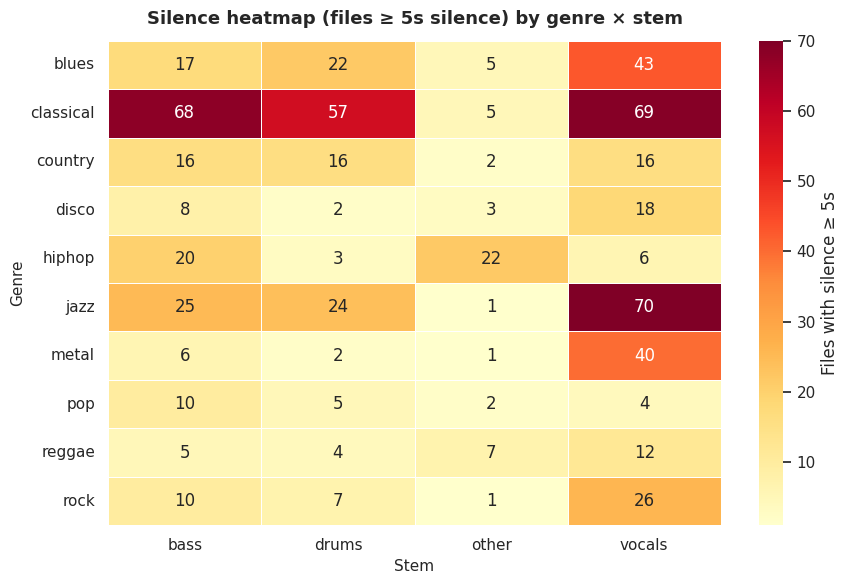

In [22]:
silence_data = {
    'blues':     {'bass': 17, 'drums': 22, 'other':  5, 'vocals': 43},
    'classical': {'bass': 68, 'drums': 57, 'other':  5, 'vocals': 69},
    'country':   {'bass': 16, 'drums': 16, 'other':  2, 'vocals': 16},
    'disco':     {'bass':  8, 'drums':  2, 'other':  3, 'vocals': 18},
    'hiphop':    {'bass': 20, 'drums':  3, 'other': 22, 'vocals':  6},
    'jazz':      {'bass': 25, 'drums': 24, 'other':  1, 'vocals': 70},
    'metal':     {'bass':  6, 'drums':  2, 'other':  1, 'vocals': 40},
    'pop':       {'bass': 10, 'drums':  5, 'other':  2, 'vocals':  4},
    'reggae':    {'bass':  5, 'drums':  4, 'other':  7, 'vocals': 12},
    'rock':      {'bass': 10, 'drums':  7, 'other':  1, 'vocals': 26},
}
silence_df = pd.DataFrame(silence_data, index=STEMS).T
 
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(silence_df, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Files with silence ≥ 5s'},
            ax=ax)
ax.set_title('Silence heatmap (files ≥ 5s silence) by genre × stem',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Stem', fontsize=11)
ax.set_ylabel('Genre', fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('silence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

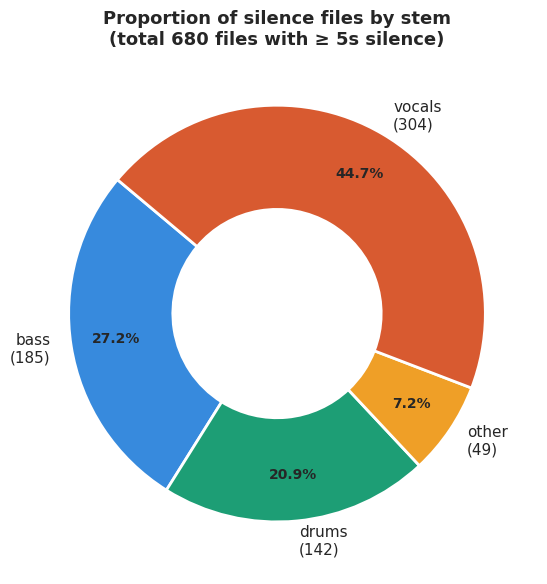

In [23]:
stem_silence_totals = {s: silence_df[s].sum() for s in STEMS}
labels  = [f"{s}\n({v})" for s, v in stem_silence_totals.items()]
sizes   = list(stem_silence_totals.values())
colors  = ['#378ADD', '#1D9E75', '#EF9F27', '#D85A30']
 
fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors, startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
 
ax.set_title('Proportion of silence files by stem\n(total 680 files with ≥ 5s silence)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stem_silence_donut.png', dpi=150, bbox_inches='tight')
plt.show()

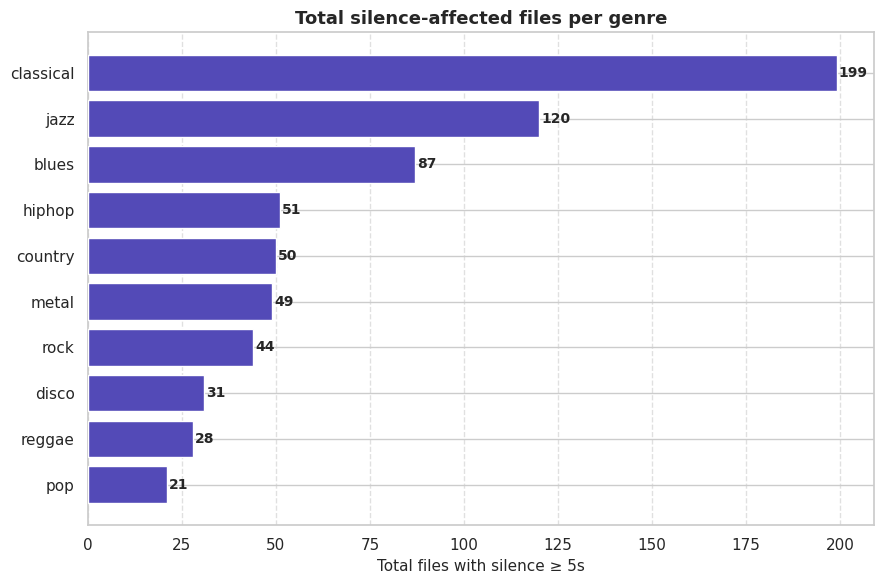

In [24]:
genre_totals = silence_df.sum(axis=1).sort_values(ascending=True)
 
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(genre_totals.index, genre_totals.values,
               color='#534AB7', edgecolor='white', zorder=3)
ax.set_xlabel('Total files with silence ≥ 5s', fontsize=11)
ax.set_title('Total silence-affected files per genre', fontsize=13, fontweight='bold')
ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
 
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=10, fontweight='bold')
 
plt.tight_layout()
plt.savefig('genre_silence_totals.png', dpi=150, bbox_inches='tight')
plt.show()

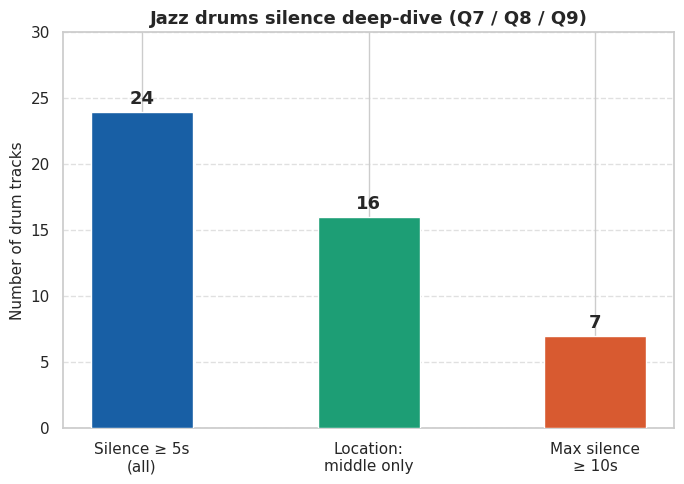

In [25]:
jazz_labels  = ['Silence ≥ 5s\n(all)', 'Location:\nmiddle only', 'Max silence\n≥ 10s']
jazz_values  = [24, 16, 7]
bar_colors   = ['#185FA5', '#1D9E75', '#D85A30']
 
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(jazz_labels, jazz_values, color=bar_colors,
              width=0.45, edgecolor='white', zorder=3)
ax.set_ylabel('Number of drum tracks', fontsize=11)
ax.set_title('Jazz drums silence deep-dive (Q7 / Q8 / Q9)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 30)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
 
for bar, val in zip(bars, jazz_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
 
plt.tight_layout()
plt.savefig('jazz_drums_deepdive.png', dpi=150, bbox_inches='tight')
plt.show()

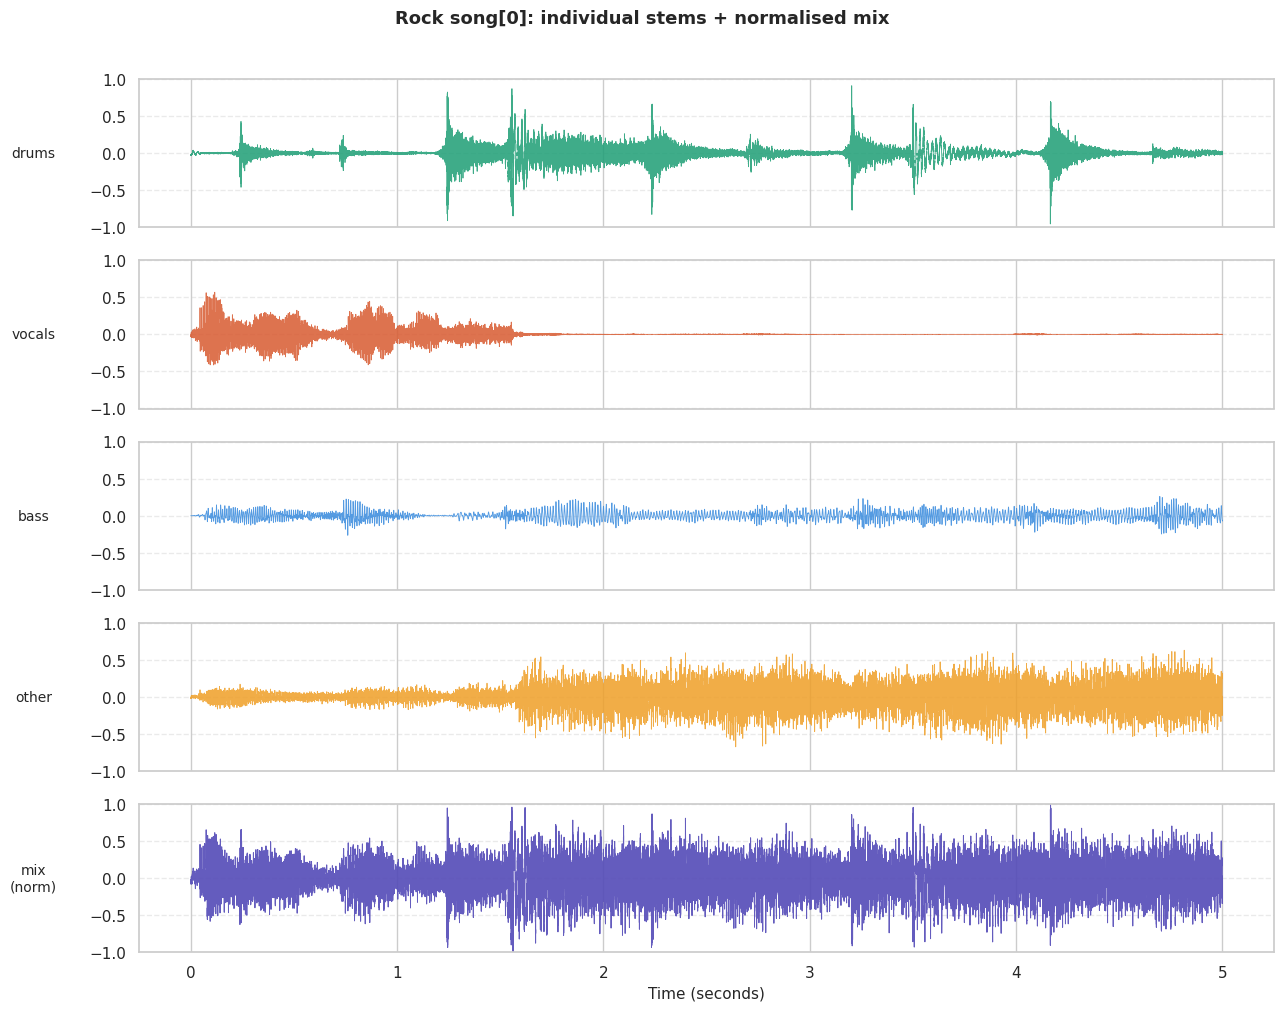

In [26]:
import librosa
import librosa.display
 
stem_labels = ['drums', 'vocals', 'bass', 'other']
stem_colors_wave = ['#1D9E75', '#D85A30', '#378ADD', '#EF9F27']
 
fig, axes = plt.subplots(len(stems_audio) + 1, 1, figsize=(13, 10), sharex=True)
 
for i, (audio, label, color) in enumerate(zip(stems_audio, stem_labels, stem_colors_wave)):
    t = np.linspace(0, len(audio)/SR, len(audio))
    axes[i].plot(t, audio, color=color, linewidth=0.6, alpha=0.85)
    axes[i].set_ylabel(label, fontsize=10, rotation=0, labelpad=40, va='center')
    axes[i].set_ylim(-1, 1)
    axes[i].yaxis.grid(True, linestyle='--', alpha=0.4)
    axes[i].set_axisbelow(True)
 

mix_norm = mix_norm
t_mix = np.linspace(0, len(mix_norm)/SR, len(mix_norm))
axes[-1].plot(t_mix, mix_norm, color='#534AB7', linewidth=0.7, alpha=0.9)
axes[-1].set_ylabel('mix\n(norm)', fontsize=10, rotation=0, labelpad=40, va='center')
axes[-1].set_ylim(-1, 1)
axes[-1].set_xlabel('Time (seconds)', fontsize=11)
axes[-1].yaxis.grid(True, linestyle='--', alpha=0.4)
axes[-1].set_axisbelow(True)
 
fig.suptitle('Rock song[0]: individual stems + normalised mix',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('waveforms.png', dpi=150, bbox_inches='tight')
plt.show()

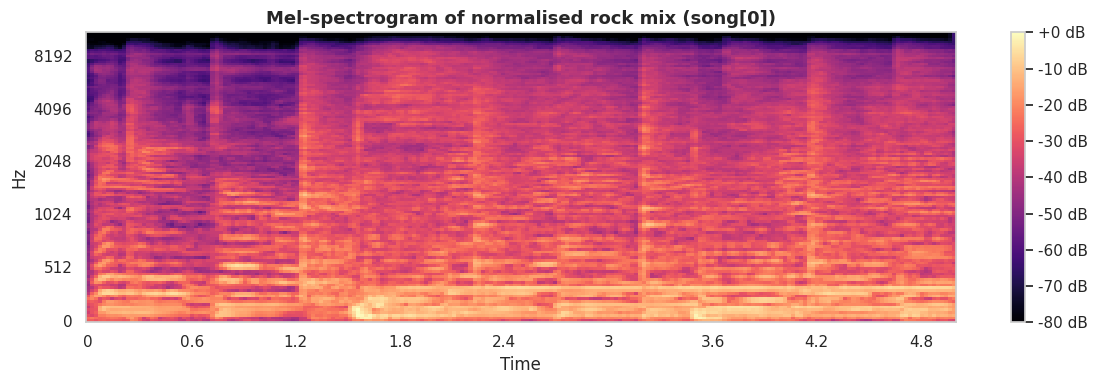

In [27]:
fig, ax = plt.subplots(figsize=(12, 4))
S = librosa.feature.melspectrogram(y=mix_norm, sr=SR,
                                    n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
S_dB = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_dB, sr=SR, hop_length=HOP_LENGTH,
                                x_axis='time', y_axis='mel', ax=ax, cmap='magma')
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set_title('Mel-spectrogram of normalised rock mix (song[0])',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('mel_spectrogram.png', dpi=150, bbox_inches='tight')
plt.show()

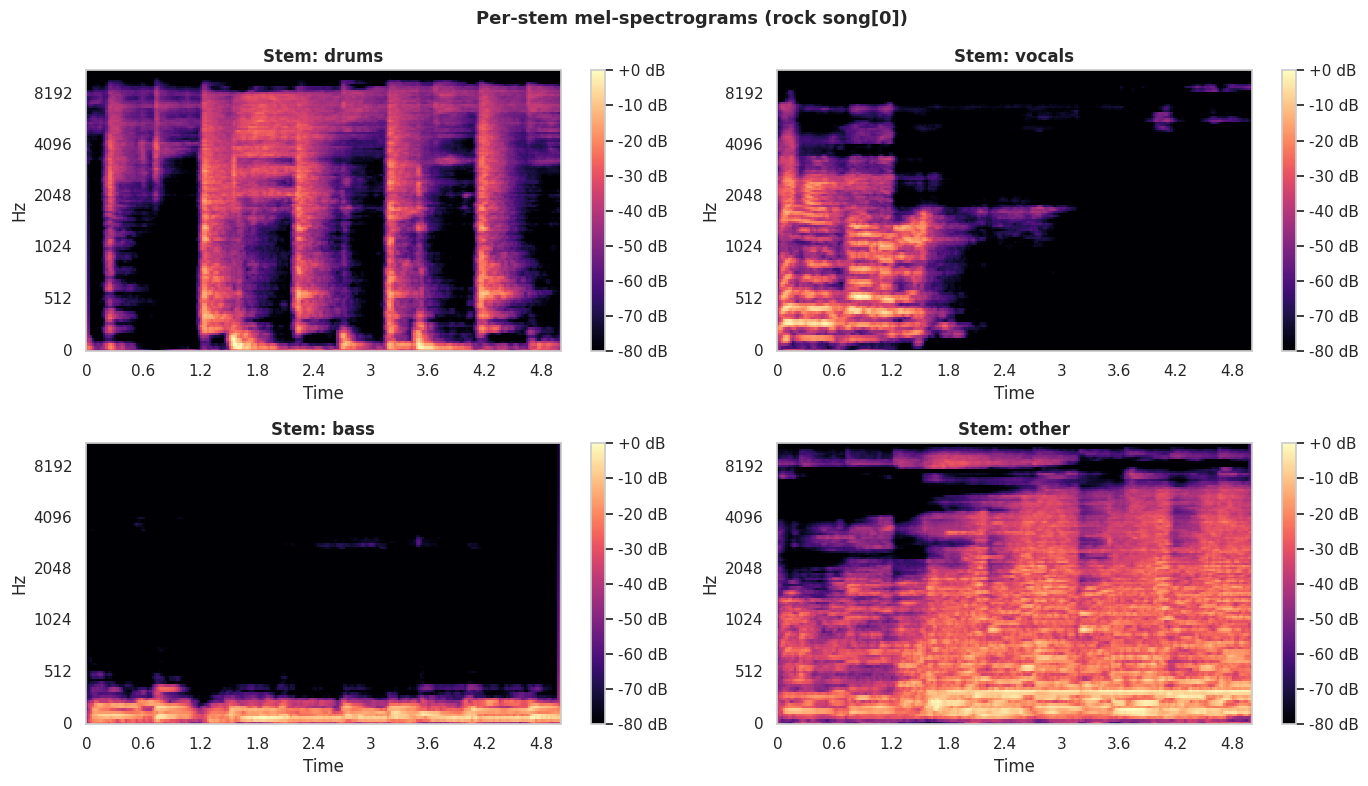

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
 
for i, (audio, label) in enumerate(zip(stems_audio, stem_labels)):
    S = librosa.feature.melspectrogram(y=audio, sr=SR,
                                        n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, sr=SR, hop_length=HOP_LENGTH,
                                    x_axis='time', y_axis='mel',
                                    ax=axes[i], cmap='magma')
    fig.colorbar(img, ax=axes[i], format='%+2.0f dB')
    axes[i].set_title(f'Stem: {label}', fontsize=12, fontweight='bold')
 
fig.suptitle('Per-stem mel-spectrograms (rock song[0])',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stem_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()